# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# Ylann Bouis

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [2]:
g, l = 9.8, 1

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [11]:
def pendulum(t, y):
    theta, omega = y
    dthetadt = omega
    domegadt = -g/l * np.sin(theta)
    return [dthetadt, domegadt]

Give you equation some initial conditions. Run the cell below.

In [4]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [27]:
t_span = (0,10)
y0 = [theta_0, omega_0]
eval = np.linspace(0, 10, 10)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [28]:
sol = solve_ivp(pendulum, t_span, y0, t_eval=eval)
theta_values = sol.y
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [13]:
print(2* np.pi * np.sqrt(l/g))

2.007089923154493


Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [14]:
print(2.0)

2.0


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [52]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None
print(f'{T_numerical: .5f}')

 0.00000


Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

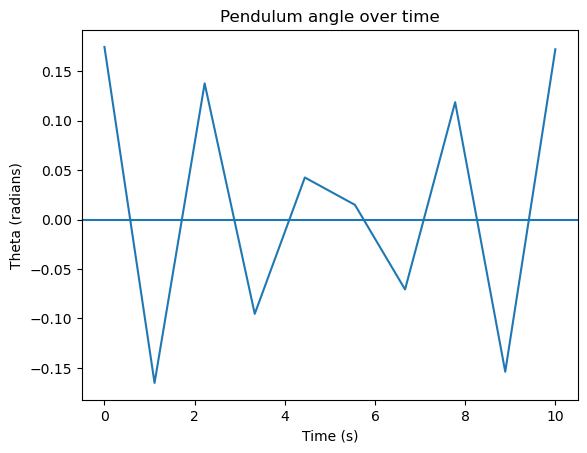

In [30]:
plt.plot(time_values, theta_values[0])
plt.title("Pendulum angle over time")
plt.xlabel("Time (s)")
plt.ylabel("Theta (radians)")
plt.axhline(y=0)
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [22]:
print(0.000)

0.0


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [ ]:
# The approximation doesn't match the numerical results at all because: 1) too few steps were taken and 2) I think something might be wrong with the code that calculates T_numerical

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [31]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [32]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [34]:
df = pd.read_csv("owid-covid-data.csv")

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [37]:
df_country = df[df['location'] == 'United States']

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [46]:
df_country = df_country[['date', 'total_cases']].dropna()
df_country['days_since_start'] = range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [47]:
df_country.head()

,date,total_cases,days_since_start
403451,2020-01-05,0.0,0
403452,2020-01-06,0.0,1
403453,2020-01-07,0.0,2
403454,2020-01-08,0.0,3
403455,2020-01-09,0.0,4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [43]:
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [44]:
# Your code here
def exponential_growth(t, C_0, r):
    return C_0 * np.exp(r * t)
# btw, this also works: exponential_growth = lambda t, C_0, r: C_0 * np.exp(r * t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [49]:
days, cases = df_country['days_since_start'].iloc[:30], df_country['total_cases'].iloc[:30]

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [50]:
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [51]:
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [54]:
print(f'{C0_fit: .2f}, {r_fit: .4f}')

 0.12,  0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [59]:
future_days = np.arange(0,60)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [60]:
predicted_cases = exponential_growth(future_days, C0_fit, r_fit)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

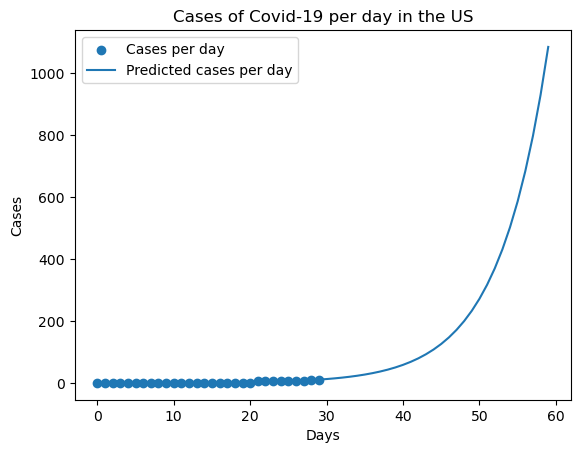

In [65]:
plt.scatter(days, cases, label="Cases per day")
plt.plot(future_days, predicted_cases, label="Predicted cases per day")
plt.xlabel("Days")
plt.ylabel("Cases")
plt.title("Cases of Covid-19 per day in the US")
plt.legend()
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [ ]:
# It fits the data pretty well for the first 30 days

Make another plot but this time to **90 days**.

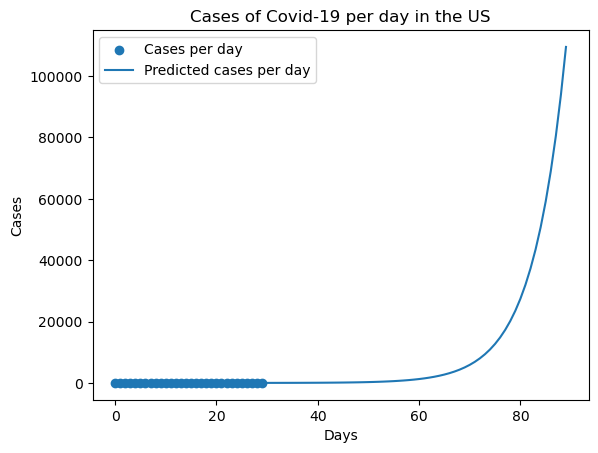

In [67]:
future_days = np.arange(0,90)
predicted_cases = exponential_growth(future_days, C0_fit, r_fit)
plt.scatter(days, cases, label="Cases per day")
plt.plot(future_days, predicted_cases, label="Predicted cases per day")
plt.xlabel("Days")
plt.ylabel("Cases")
plt.title("Cases of Covid-19 per day in the US")
plt.legend()
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [68]:
print(exponential_growth(87, C0_fit, r_fit))

80497.11186068892


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

<Axes: xlabel='petal_length', ylabel='petal_width'>

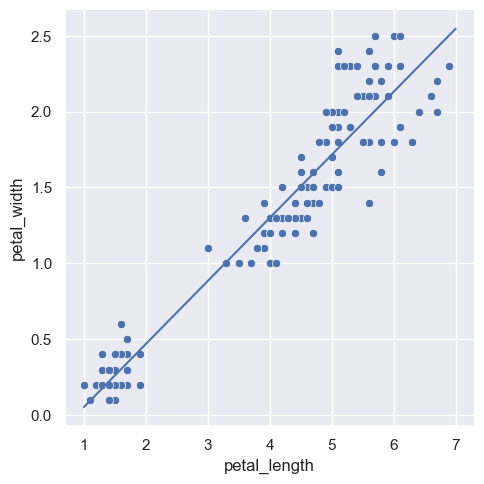

In [83]:
import seaborn as sns
iris = sns.load_dataset("iris")
sns.set_theme()
sns.relplot(
    data=iris,
    x="petal_length", y="petal_width"
)
petal_lengths = iris['petal_length']
petal_width = iris['petal_width']
def lin_model(x, m, b):
    return m*x + b

df = pd.DataFrame()
popt, pcov = curve_fit(lin_model, petal_lengths, petal_width)
df['model_lengths'] = np.arange(1, 8)
df['model_widths'] = lin_model(model_lengths, popt[0], popt[1])
sns.lineplot(
    data=df,
    x='model_lengths', y='model_widths'
)

On it's own branch, submit this notebook to Gradescope! 